In [ ]:
import sqlite3


conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()


cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')


sample_data = [
    ('Product A', 10, 15.5),
    ('Product B', 5, 25.0),
    ('Product A', 8, 15.5),
    ('Product C', 3, 40.0),
    ('Product B', 7, 25.0),
]

cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()
conn.close()


In [ ]:
import sqlite3
import pandas as pd


conn = sqlite3.connect('sales_data.db')


query = """
SELECT 
    product, 
    SUM(quantity) AS total_qty, 
    SUM(quantity * price) AS revenue 
FROM sales 
GROUP BY product
"""


df = pd.read_sql_query(query, conn)
conn.close()


print(df)


     product  total_qty  revenue
0  Product A         36    558.0
1  Product B         24    600.0
2  Product C          6    240.0


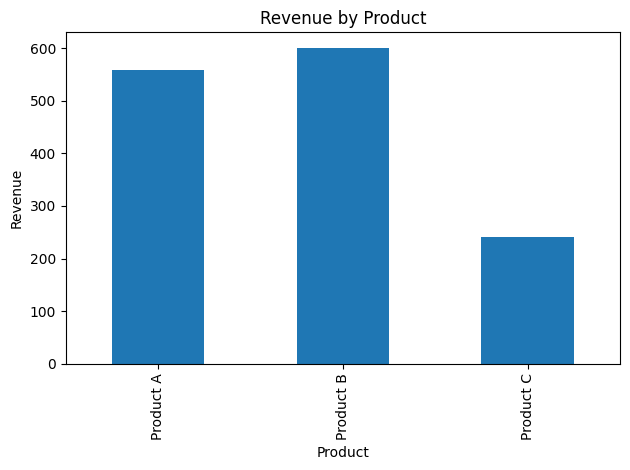

In [ ]:
import matplotlib.pyplot as plt


df.plot(kind='bar', x='product', y='revenue', legend=False)
plt.title('Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig('sales_chart.png')  
plt.show()
